# Clustering

In [1]:
import pandas as pd
import os
import json
import numpy as np
import matplotlib.pyplot as plt

**Dynamic Time Warping**

In [2]:
#read in all videos
all_videos = pd.read_csv('all_videos.csv')

In [3]:
all_videos.head()

,alphapose_file,Dance,alphapose_coordinates,normalised_alphapose,dancing,people,video_id,video_metrics,followers,likes,comments,desc,dancing_encoded
0,alphapose-results-video_7401324200356531461.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...",[[ 0. 0. 10.02052307 .....,no,4,7401324200356531461,"{'followers': 22600, 'likes': '78.2K likes', '...",22600,78200,623,“ya la vieron👀”,0
1,alphapose-results-video_7423107618173947141.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...",[[ 0. 0. 18.10678101 .....,no,2,7423107618173947141,"{'followers': 7000000, 'likes': '87.3K likes',...",7000000,87300,1073,“#duet with @Brianna #POV You live in a world...,0
2,alphapose-results-video_7405720331949853957.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...",[[ 0. 0. 0. .....,no,0,7405720331949853957,"{'followers': 244700, 'likes': '470.6K likes',...",244700,470600,4786,“¿Funciona Lovette feromonas?🤢😡”,0
3,alphapose-results-video_7397542554331303174.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...",[[ 0. 0. 21.10412598 .....,yes,1,7397542554331303174,"{'followers': 44100000, 'likes': '461.9K likes...",44100000,461900,10400,“comenten emojis verdes 💚”,1
4,alphapose-results-video_7391225934390545694.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...",[[ 0. 0. 44.43899536 .....,yes,1,7391225934390545694,"{'followers': 2600000, 'likes': '89.3K likes',...",2600000,89300,215,“dance creds: @Kelley Heyer”,1


In [4]:
#load json files
def load_json(row):
    dance_folder = row['Dance'] #folder name (same as dance)
    filename = row['alphapose_file'] #filename
    json_path = os.path.join("alphapose_json", dance_folder, filename) #get path
    
    if os.path.exists(json_path):
        with open(json_path, 'r') as file:
            return json.load(file) #load file
    return None

In [5]:
#extract coordinates and normalise them 
def normalise_coordinates(row):
    alphapose = row['alphapose_coordinates']
        
    frames = {}
    for frame in alphapose:
        image_id = frame.get('image_id').split('.')[0] #get the frame number
        keypoints = frame.get('keypoints') #get keypoints
        
        if image_id not in frames: #one set of coordinates per frame (ensures only 1 person per video)
            frames[image_id] = {'keypoints': keypoints}
    
    normalised_frames = []
    for image_id, data in sorted(frames.items()):
        keypoints = data['keypoints']
        frame_coords = []
        
        for i in range(0, len(keypoints), 3):
            x, y, score = keypoints[i:i+3]
            #take those with confidence scores above 0.5 otherwise (0,0)
            if score >= 0.5:
                frame_coords.append((x, y))
            else:
                frame_coords.append((0, 0))
        
        #normalise by nose
        nose_x, nose_y = frame_coords[0]
        normalised_frame = []
        for x, y in frame_coords:
            normalised_frame.extend([x - nose_x, y - nose_y])
        normalised_frames.append(normalised_frame)
        
    return np.array(normalised_frames)

In [6]:
#apply to data
all_videos["alphapose_coordinates"] = all_videos.apply(load_json, axis=1)
all_videos["normalised_alphapose"] = all_videos.apply(normalise_coordinates, axis=1)

In [7]:
#get dancing videos only
videos_dancing = all_videos[all_videos['dancing'] == 'yes']

In [8]:
dance_coords = {}

for dance, group in videos_dancing.groupby('Dance'): #group by dance trend
    video_coords = []
    max_frames = 0 #resets for each dance
    
    for idx, row in group.iterrows():
        coords = row['normalised_alphapose']
        coords = coords.reshape(-1, 17, 2) #ensure coordinates in correct shape
        max_frames = max(max_frames, coords.shape[0]) #obtains max frames of all videos
        video_coords.append(coords)
        
    padded_video_coords = []
    
    #pads array with zeros to max length
    for coords in video_coords:
        pad_width = max_frames - coords.shape[0]
        padded_coords = np.pad(coords, ((0, pad_width), (0, 0), (0, 0)), mode = 'constant', constant_values = 0)
        padded_video_coords.append(padded_coords)
        
    dance_coords[dance] = np.stack(padded_video_coords, axis=0) #stack videos for each dance

In [9]:
#combine all coordinates into a list
sequences = []
for dance, coords in dance_coords.items():
    print(coords.shape)
    sequences += [i for i in coords]


(386, 4906, 17, 2)
(351, 948, 17, 2)
(264, 1057, 17, 2)
(341, 1081, 17, 2)
(157, 996, 17, 2)


In [13]:
len(sequences)

1499

In [ ]:
#dynamic time warping
from dtaidistance import dtw_ndim, dtw
dtw_matrix = dtw_ndim.distance_matrix_fast(sequences)
print(dtw_matrix)

In [ ]:
#save dtw matrix
df = pd.DataFrame(dtw_matrix)
df.to_csv('dtw_matrix.csv', index=False)

**Clustering**

In [10]:
#read dtw matrix
dtw_matrix = pd.read_csv('dtw_matrix.csv').values

In [11]:
#upper triangle of matrix - upper and lower triangle same 
upper = dtw_matrix[np.triu_indices(dtw_matrix.shape[0], k = 1)]

In [12]:
#hierarchical cluster using different linakges
from scipy.cluster.hierarchy import dendrogram, linkage

Z1 = linkage(upper, method='single')
Z2 = linkage(upper, method='complete')
Z3 = linkage(upper, method='average')
Z4 = linkage(upper, method='ward')

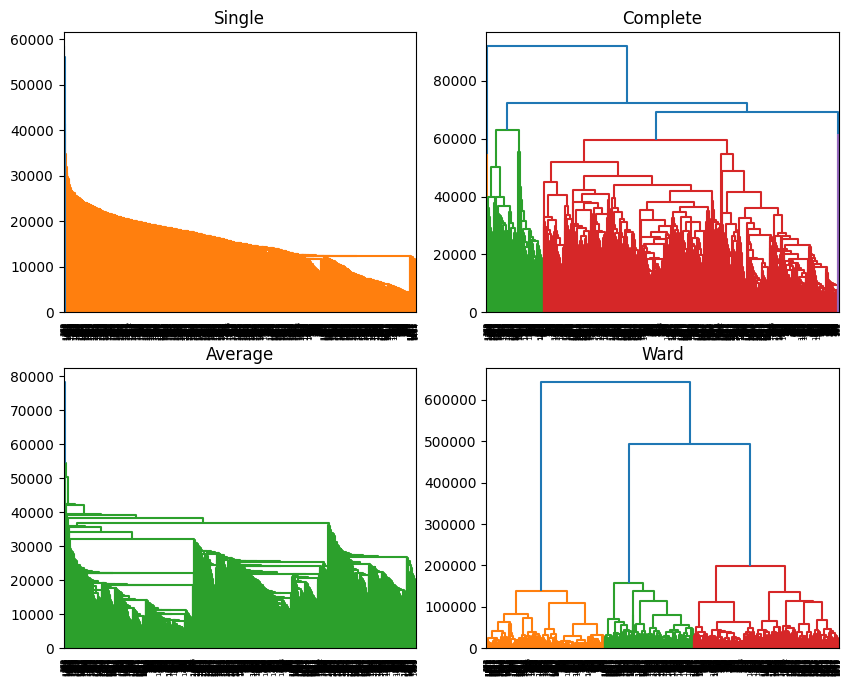

In [14]:
#plot dendrogams for them all
plt.figure(figsize=(10, 8))
plt.subplot(2,2,1), dendrogram(Z1), plt.title('Single')
plt.subplot(2,2,2), dendrogram(Z2), plt.title('Complete')
plt.subplot(2,2,3), dendrogram(Z3), plt.title('Average')
plt.subplot(2,2,4), dendrogram(Z4), plt.title('Ward')
plt.show()

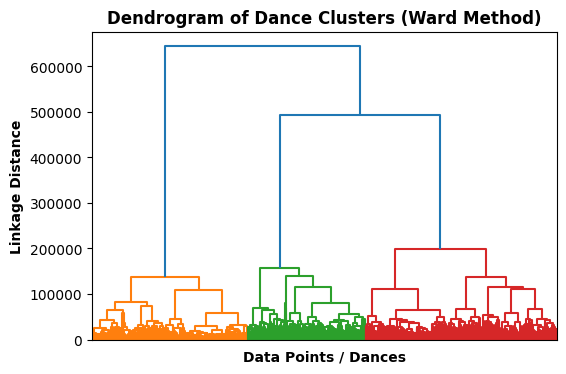

In [18]:
#plot best linakge
plt.figure(figsize=(6, 4)) 
dendrogram(Z4, no_labels=True)
#sns.set_context("poster", font_scale=0.8)
plt.xlabel("Data Points / Dances", fontweight = 'bold')
plt.ylabel("Linkage Distance", fontweight = 'bold')
plt.title("Dendrogram of Dance Clusters (Ward Method)", fontweight = 'bold')
#plt.savefig('dendrogram_3.png', format = 'png', dpi=300, bbox_inches='tight')

plt.show()


In [19]:
#get clusters for each - 5 for 5 videos
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

cluster_labels_heir_Z1 = fcluster(Z1, 5, criterion='maxclust')
cluster_labels_heir_Z2 = fcluster(Z2, 5, criterion='maxclust')
cluster_labels_heir_Z3 = fcluster(Z3, 5, criterion='maxclust')
cluster_labels_heir_Z4 = fcluster(Z4, 5, criterion='maxclust')

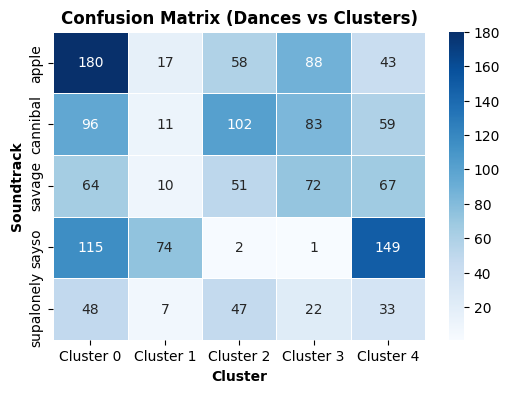

In [20]:
#plot confusion matrix for clustering algorithm
from sklearn.metrics import confusion_matrix
import seaborn as sns

#sns.set_context("poster", font_scale=0.8)
cluster_labels_heir_Z = cluster_labels_heir_Z4.copy() #get the labels, changeable for each linkage by changing Z4
cluster_labels_heir_Z -= np.min(cluster_labels_heir_Z)

#dance labels based on number of videos in each
dance_labels = (
    ['apple'] * dance_coords['apple'].shape[0] +
    ['cannibal'] * dance_coords['cannibal'].shape[0] +
    ['savage'] * dance_coords['savage'].shape[0] +
    ['sayso'] * dance_coords['sayso'].shape[0] +
    ['supalonely'] * dance_coords['supalonely'].shape[0]
)

#sort labels
dance_to_index = {dance: i for i, dance in enumerate(sorted(set(dance_labels)))}
dance_numeric_labels = [dance_to_index[dance] for dance in dance_labels]

#create matrix
conf_matrix_heir_Z = confusion_matrix(dance_numeric_labels, cluster_labels_heir_Z)

#put labels into a df for easy plotting
cluster_names_heir_Z = [f"Cluster {i}" for i in sorted(set(cluster_labels_heir_Z))]
conf_matrix_df_heir_Z = pd.DataFrame(conf_matrix_heir_Z, index=dance_to_index.keys(), columns=cluster_names_heir_Z)

#plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_df_heir_Z, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Cluster", fontweight = 'bold')
plt.ylabel("Soundtrack", fontweight = 'bold')
plt.title("Confusion Matrix (Dances vs Clusters)", fontweight = 'bold')
#plt.savefig('conf_matrix_3.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
#metrics of cluster labels
from sklearn import metrics
print(f"hierarchical accuracy: {metrics.accuracy_score(dance_numeric_labels, cluster_labels_heir_Z) * 100:.2f}%")
print(f"hierarchical f1: {metrics.f1_score(dance_numeric_labels, cluster_labels_heir_Z, average = 'weighted') * 100:.2f}%")
print(f"hierarchical recall: {metrics.recall_score(dance_numeric_labels, cluster_labels_heir_Z, average = 'weighted') * 100:.2f}%")
print(f"hierarchical precision: {metrics.precision_score(dance_numeric_labels, cluster_labels_heir_Z, average = 'weighted') * 100:.2f}%")

hierarchical accuracy: 18.41%
hierarchical f1: 16.39%
hierarchical recall: 18.41%
hierarchical precision: 15.90%


**Clustering with No Pole**

In [10]:
#read in all videos with no pole
all_videos_2 = pd.read_csv('all_videos_2.csv')

In [11]:
all_videos_2["alphapose_coordinates"] = all_videos_2.apply(load_json, axis=1)
all_videos_2["normalised_alphapose"] = all_videos_2.apply(normalise_coordinates, axis=1)

In [13]:
#extract dancing videos
videos_dancing_2 = all_videos_2[all_videos_2['dancing'] == 'yes']

In [14]:
dance_coords_2 = {}

for dance, group in videos_dancing_2.groupby('Dance'): #group by dance trend
    video_coords = []
    max_frames = 0 #resets for each dance
    
    for idx, row in group.iterrows():
        coords = row['normalised_alphapose']
        coords = coords.reshape(-1, 17, 2) #ensure coordinates in correct shape
        max_frames = max(max_frames, coords.shape[0]) #obtains max frames of all videos
        video_coords.append(coords)
        
    padded_video_coords = []
    
    #pads array with zeros to max length
    for coords in video_coords:
        pad_width = max_frames - coords.shape[0]
        padded_coords = np.pad(coords, ((0, pad_width), (0, 0), (0, 0)), mode = 'constant', constant_values = 0)
        padded_video_coords.append(padded_coords)
        
    dance_coords_2[dance] = np.stack(padded_video_coords, axis=0) #stack videos for each dance

In [15]:
#combine all coordinates into a list
sequences_2 = []
for dance, coords in dance_coords_2.items():
    print(coords.shape)
    sequences_2 += [i for i in coords]


(386, 4906, 17, 2)
(351, 948, 17, 2)
(200, 619, 17, 2)
(264, 1057, 17, 2)
(341, 1081, 17, 2)
(157, 996, 17, 2)


In [27]:
len(sequences_2)

1699

In [ ]:
#dtw on sequences
from dtaidistance import dtw_ndim, dtw
dtw_matrix_2 = dtw_ndim.distance_matrix_fast(sequences_2)
print(dtw_matrix_2)

In [ ]:
#save dtw matrix
df = pd.DataFrame(dtw_matrix_2)
df.to_csv('dtw_matrix_2.csv', index=False)

In [15]:
#load dtw matrix
dtw_matrix_2 = pd.read_csv('dtw_matrix_2.csv').values

In [17]:
dtw_matrix_2

array([[    0.        , 29217.50885465, 23292.50705791, ...,
        26410.89604703, 33363.15261013, 39908.54067986],
       [29217.50885465,     0.        , 25137.82941366, ...,
        31114.38692337, 29844.3379186 , 36991.95358158],
       [23292.50705791, 25137.82941366,     0.        , ...,
        28293.61828665, 33351.47249122, 39616.56721826],
       ...,
       [26410.89604703, 31114.38692337, 28293.61828665, ...,
            0.        , 27575.02539937, 33210.88108678],
       [33363.15261013, 29844.3379186 , 33351.47249122, ...,
        27575.02539937,     0.        , 20498.12199836],
       [39908.54067986, 36991.95358158, 39616.56721826, ...,
        33210.88108678, 20498.12199836,     0.        ]])

In [16]:
#upper triangle of matrix - upper and lower triangle same 
upper2 = dtw_matrix_2[np.triu_indices(dtw_matrix_2.shape[0], k = 1)]

In [17]:
#hierarchical clustering using different linkage
from scipy.cluster.hierarchy import dendrogram, linkage

Z1 = linkage(upper2, method='single')
Z2 = linkage(upper2, method='complete')
Z3 = linkage(upper2, method='average')
Z4 = linkage(upper2, method='ward')

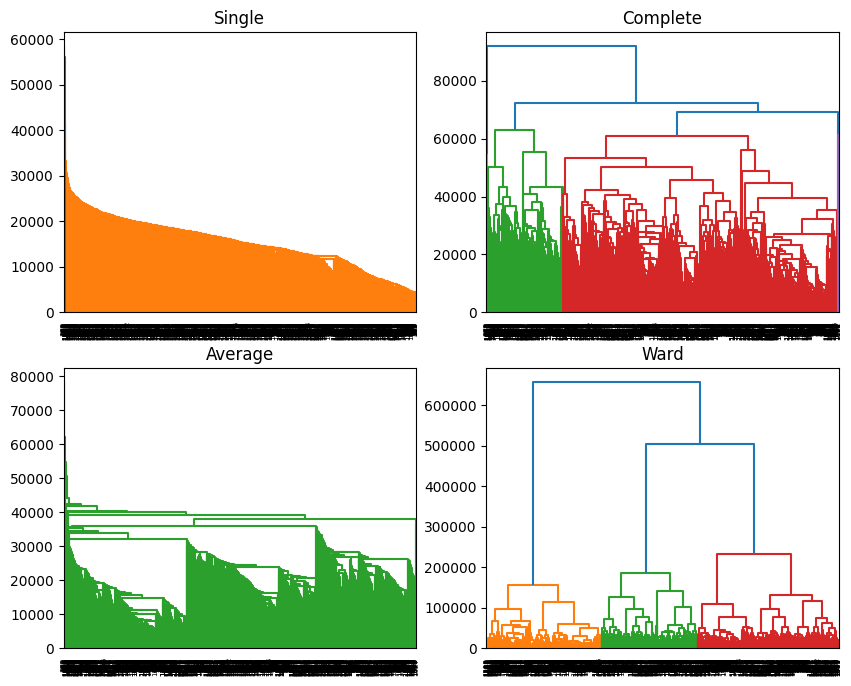

In [18]:
#plot dendrograms
plt.figure(figsize=(10, 8))
plt.subplot(2,2,1), dendrogram(Z1), plt.title('Single')
plt.subplot(2,2,2), dendrogram(Z2), plt.title('Complete')
plt.subplot(2,2,3), dendrogram(Z3), plt.title('Average')
plt.subplot(2,2,4), dendrogram(Z4), plt.title('Ward')
plt.show()

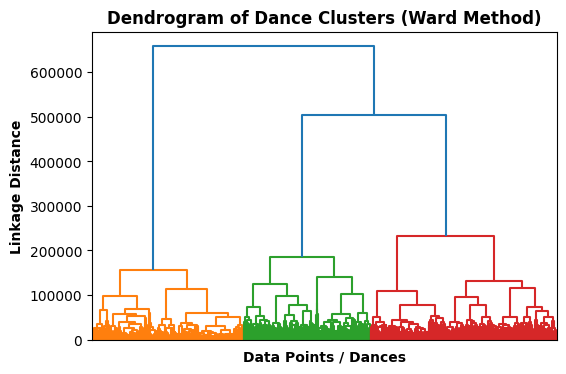

In [21]:
#plot best linkage
plt.figure(figsize=(6, 4))
dendrogram(Z4, no_labels=True)
#sns.set_context("poster", font_scale=0.8)
plt.xlabel("Data Points / Dances", fontweight = 'bold')
plt.ylabel("Linkage Distance", fontweight = 'bold')
plt.title("Dendrogram of Dance Clusters (Ward Method)", fontweight = 'bold')
#plt.savefig('dendrogram_new_data_2.png', format = 'png', dpi=300, bbox_inches='tight')

plt.show()


In [22]:
#cluster labels for each linkage - 6 for 6 videos
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

cluster_labels_heir_Z1 = fcluster(Z1, 6, criterion='maxclust')
cluster_labels_heir_Z2 = fcluster(Z2, 6, criterion='maxclust')
cluster_labels_heir_Z3 = fcluster(Z3, 6, criterion='maxclust')
cluster_labels_heir_Z4 = fcluster(Z4, 6, criterion='maxclust')

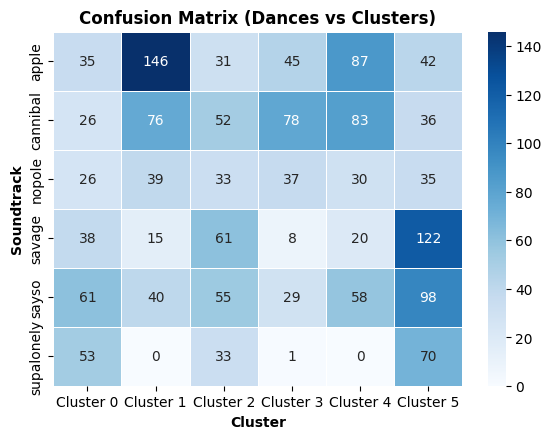

In [27]:
#plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

#sns.set_context("poster", font_scale=0.8)
cluster_labels_heir_Z = cluster_labels_heir_Z4.copy()
cluster_labels_heir_Z -= np.min(cluster_labels_heir_Z) #get the labels, changeable for each linkage by changing Z4

#dance labels based on number of videos in each
dance_labels_2 = (
    ['apple'] * dance_coords_2['apple'].shape[0] +
    ['cannibal'] * dance_coords_2['cannibal'].shape[0] +
    ['savage'] * dance_coords_2['savage'].shape[0] +
    ['sayso'] * dance_coords_2['sayso'].shape[0] +
    ['supalonely'] * dance_coords_2['supalonely'].shape[0] +
    ['nopole'] * dance_coords_2['nopole'].shape[0]
)

#sort labels
dance_to_index_2 = {dance: i for i, dance in enumerate(sorted(set(dance_labels_2)))}
dance_numeric_labels_2 = [dance_to_index_2[dance] for dance in dance_labels_2]

#create confusion matrix
conf_matrix_heir_Z = confusion_matrix(dance_numeric_labels_2, cluster_labels_heir_Z)

#put labels into a df for easy plotting
cluster_names_heir_Z = [f"Cluster {i}" for i in sorted(set(cluster_labels_heir_Z))]
conf_matrix_df_heir_Z = pd.DataFrame(conf_matrix_heir_Z, index=dance_to_index_2.keys(), columns=cluster_names_heir_Z)

#plot matrix
plt.figure(figsize=(6.6, 4.6))
sns.heatmap(conf_matrix_df_heir_Z, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Cluster", fontweight = 'bold')
plt.ylabel("Soundtrack", fontweight = 'bold')
plt.yticks(rotation=90) 
plt.title("Confusion Matrix (Dances vs Clusters)", fontweight = 'bold')
plt.savefig('conf_matrix_new_data_2.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
#metrics for clustering
print(f"hierarchical accuracy: {metrics.accuracy_score(dance_numeric_labels_2, cluster_labels_heir_Z) * 100:.2f}%")
print(f"hierarchical f1: {metrics.f1_score(dance_numeric_labels_2, cluster_labels_heir_Z, average = 'weighted') * 100:.2f}%")
print(f"hierarchical recall: {metrics.recall_score(dance_numeric_labels_2, cluster_labels_heir_Z, average = 'weighted') * 100:.2f}%")
print(f"hierarchical precision: {metrics.precision_score(dance_numeric_labels_2, cluster_labels_heir_Z, average = 'weighted') * 100:.2f}%")

hierarchical accuracy: 16.48%
hierarchical f1: 15.53%
hierarchical recall: 16.48%
hierarchical precision: 16.18%


**DTW on Test Data**

In [19]:
#five test sequences, 10 videos, number of frames, keypoints, (x,y) cooridnates, values between -1312 and 1312
test_seq1 = np.random.uniform(-1312, 1312, (10, 1386, 17, 2))
test_seq2 = np.random.uniform(-1312, 1312, (10, 974, 17, 2))                          
test_seq3 = np.random.uniform(-1312, 1312, (10, 672, 17, 2))
test_seq4 = np.random.uniform(-1312, 1312, (10, 1629, 17, 2))
test_seq5 = np.random.uniform(-1312, 1312, (10, 453, 17, 2))

In [20]:
#put frames together
test_sequences = []
for ts in [test_seq1, test_seq2, test_seq3, test_seq4, test_seq5]:
    test_sequences += [ i for i in ts ]

In [21]:
#run dtw on sequences
from dtaidistance import dtw_ndim, dtw
dtw_matrix = dtw_ndim.distance_matrix_fast(test_sequences)
print(dtw_matrix)

[[     0.         155194.55650967 155789.10993164 ... 142869.61333023
  143397.1530607  143525.21283619]
 [155194.55650967      0.         155212.25992259 ... 142585.55001668
  142704.78197304 143059.54473312]
 [155789.10993164 155212.25992259      0.         ... 142239.69334743
  142846.2393653  142871.52859729]
 ...
 [142869.61333023 142585.55001668 142239.69334743 ...      0.
   89135.80657789  89290.32223958]
 [143397.1530607  142704.78197304 142846.2393653  ...  89135.80657789
       0.          88712.7915744 ]
 [143525.21283619 143059.54473312 142871.52859729 ...  89290.32223958
   88712.7915744       0.        ]]


In [22]:
#extract upper
upper = dtw_matrix[np.triu_indices(dtw_matrix.shape[0], k = 1)]

In [23]:
#try all linkages
from scipy.cluster.hierarchy import dendrogram, linkage

Z1 = linkage(dtw_matrix, method='single')
Z2 = linkage(dtw_matrix, method='complete')
Z3 = linkage(dtw_matrix, method='average')
Z4 = linkage(dtw_matrix, method='ward')

/tmp/ipykernel_4000148/2048128262.py:4: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z1 = linkage(dtw_matrix, method='single')
/tmp/ipykernel_4000148/2048128262.py:5: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z2 = linkage(dtw_matrix, method='complete')
/tmp/ipykernel_4000148/2048128262.py:6: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z3 = linkage(dtw_matrix, method='average')
/tmp/ipykernel_4000148/2048128262.py:7: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z4 = linkage(dtw_matrix, method='ward')


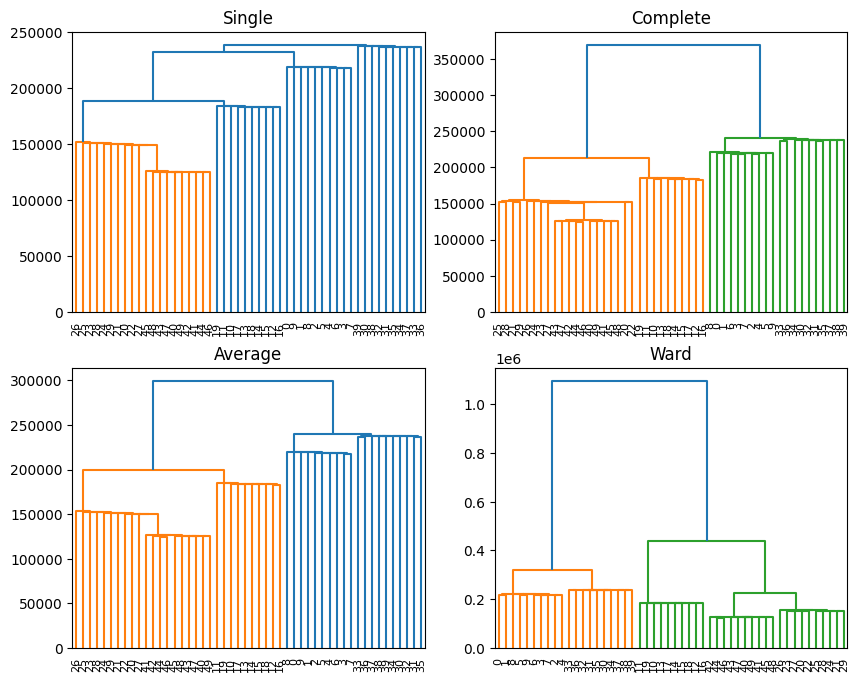

In [24]:
#plot different linkages
plt.figure(figsize=(10, 8))
plt.subplot(2,2,1), dendrogram(Z1), plt.title('Single')
plt.subplot(2,2,2), dendrogram(Z2), plt.title('Complete')
plt.subplot(2,2,3), dendrogram(Z3), plt.title('Average')
plt.subplot(2,2,4), dendrogram(Z4), plt.title('Ward')
plt.show()

In [43]:
#cluster labels - 5 for 5 sequences
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

cluster_labels_heir_Z1 = fcluster(Z1, 5, criterion='maxclust')
cluster_labels_heir_Z2 = fcluster(Z2, 5, criterion='maxclust')
cluster_labels_heir_Z3 = fcluster(Z3, 5, criterion='maxclust')
cluster_labels_heir_Z4 = fcluster(Z4, 5, criterion='maxclust')

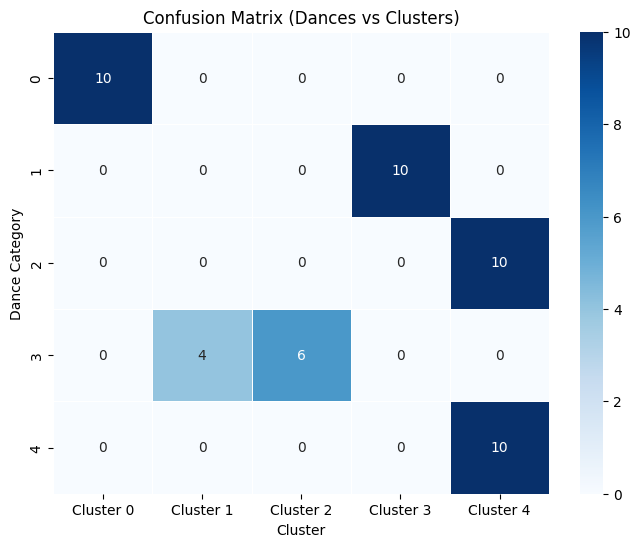

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cluster_labels_heir_Z = cluster_labels_heir_Z4.copy()
cluster_labels_heir_Z -= np.min(cluster_labels_heir_Z)

#labels based on test sequences
labels = [0]*test_seq1.shape[0] + [1]*test_seq2.shape[0] + [2]*test_seq3.shape[0] + [3]*test_seq4.shape[0] + [4]*test_seq5.shape[0]

#create confusion matrix
conf_matrix_heir_Z = confusion_matrix(labels, cluster_labels_heir_Z)

#labels in df
cluster_names_heir_Z = [f"Cluster {i}" for i in sorted(set(cluster_labels_heir_Z))]
conf_matrix_df_heir_Z = pd.DataFrame(conf_matrix_heir_Z, index=[0, 1, 2, 3, 4], columns=cluster_names_heir_Z)

#plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df_heir_Z, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Cluster")
plt.ylabel("Dance Category")
plt.title("Confusion Matrix (Dances vs Clusters)")
plt.show()

In [45]:
#get metrics
from sklearn import metrics
print(f"hierarchical accuracy: {metrics.accuracy_score(labels, cluster_labels_heir_Z) * 100:.2f}%")
print(f"hierarchical f1: {metrics.f1_score(labels, cluster_labels_heir_Z, average = 'weighted') * 100:.2f}%")
print(f"hierarchical recall: {metrics.recall_score(labels, cluster_labels_heir_Z, average = 'weighted') * 100:.2f}%")
print(f"hierarchical precision: {metrics.precision_score(labels, cluster_labels_heir_Z, average = 'weighted') * 100:.2f}%")

hierarchical accuracy: 40.00%
hierarchical f1: 33.33%
hierarchical recall: 40.00%
hierarchical precision: 30.00%


**Trying Different Clustering Algorithms**

In [ ]:
#a lot of these don't work properly

In [31]:
normalised_alphapose = all_videos['normalised_alphapose']

In [32]:
#find max frames
max_frames = max(normalised_alphapose.apply(lambda x: x.shape[0]))
print(max_frames)

10788


In [33]:
#pad each array with zeros to max frame length 
def pad_array(arr, max_padding = max_frames):
    
    arr = np.array(arr)
    padding = max_padding - arr.shape[0]
    if padding > 0:
        arr = np.pad(arr, ((0, padding), (0, 0)), mode = 'constant', constant_values = 0)

    return arr

In [34]:
#pad coordinates
all_videos['padded_normalised_alphapose'] = all_videos['normalised_alphapose'].apply(lambda x: pad_array(x, max_frames))

In [35]:
#getting normalised and padded coordiantes for all dances

In [36]:
apple_coords = all_videos.loc[(all_videos['Dance'] == 'apple') & (all_videos['dancing'] == 'yes'), 'normalised_alphapose']

In [37]:
apple_coords_padded = all_videos.loc[(all_videos['Dance'] == 'apple') & (all_videos['dancing'] == 'yes'), 'padded_normalised_alphapose']

In [38]:
savage_coords = all_videos.loc[(all_videos['Dance'] == 'savage') & (all_videos['dancing'] == 'yes'), 'normalised_alphapose']

In [39]:
savage_coords_padded = all_videos.loc[(all_videos['Dance'] == 'savage') & (all_videos['dancing'] == 'yes'), 'padded_normalised_alphapose']

In [40]:
sayso_coords = all_videos.loc[(all_videos['Dance'] == 'sayso') & (all_videos['dancing'] == 'yes'), 'normalised_alphapose']

In [41]:
sayso_coords_padded = all_videos.loc[(all_videos['Dance'] == 'sayso') & (all_videos['dancing'] == 'yes'), 'padded_normalised_alphapose']

In [42]:
cannibal_coords = all_videos.loc[(all_videos['Dance'] == 'cannibal') & (all_videos['dancing'] == 'yes'), 'normalised_alphapose']

In [43]:
cannibal_coords_padded = all_videos.loc[(all_videos['Dance'] == 'cannibal') & (all_videos['dancing'] == 'yes'), 'padded_normalised_alphapose']

In [44]:
supalonely_coords = all_videos.loc[(all_videos['Dance'] == 'supalonely') & (all_videos['dancing'] == 'yes'), 'normalised_alphapose']

In [46]:
supalonely_coords_padded = all_videos.loc[(all_videos['Dance'] == 'supalonely') & (all_videos['dancing'] == 'yes'), 'padded_normalised_alphapose']

In [ ]:
#trying different ways of storing all coords

In [47]:
apple_coords_list = [np.array(seq) for seq in apple_coords]
savage_coords_list = [np.array(seq) for seq in savage_coords]
sayso_coords_list = [np.array(seq) for seq in sayso_coords]
cannibal_coords_list = [np.array(seq) for seq in cannibal_coords]
supalonely_coords_list = [np.array(seq) for seq in supalonely_coords]

#combine into one list
all_videos_coords = apple_coords_list + savage_coords_list + sayso_coords_list + cannibal_coords_list + supalonely_coords_list

In [48]:
#put all videos in dictionary
all_videos_dict = {
    "apple": [np.array(seq) for seq in apple_coords],
    "savage": [np.array(seq) for seq in savage_coords],
    "sayso": [np.array(seq) for seq in sayso_coords],
    "cannibal": [np.array(seq) for seq in cannibal_coords],
    "supalonely": [np.array(seq) for seq in supalonely_coords]
}


In [49]:
for i, video in enumerate(all_videos_coords):
    print(f"Video {i} shape: {video.shape}")


Video 0 shape: (445, 34)
Video 1 shape: (450, 34)
Video 2 shape: (451, 34)
Video 3 shape: (450, 34)
Video 4 shape: (451, 34)
Video 5 shape: (451, 34)
Video 6 shape: (486, 34)
Video 7 shape: (297, 34)
Video 8 shape: (453, 34)
Video 9 shape: (299, 34)
Video 10 shape: (452, 34)
Video 11 shape: (588, 34)
Video 12 shape: (451, 34)
Video 13 shape: (451, 34)
Video 14 shape: (451, 34)
Video 15 shape: (451, 34)
Video 16 shape: (453, 34)
Video 17 shape: (451, 34)
Video 18 shape: (452, 34)
Video 19 shape: (883, 34)
Video 20 shape: (451, 34)
Video 21 shape: (452, 34)
Video 22 shape: (451, 34)
Video 23 shape: (451, 34)
Video 24 shape: (459, 34)
Video 25 shape: (450, 34)
Video 26 shape: (451, 34)
Video 27 shape: (510, 34)
Video 28 shape: (451, 34)
Video 29 shape: (452, 34)
Video 30 shape: (437, 34)
Video 31 shape: (451, 34)
Video 32 shape: (451, 34)
Video 33 shape: (450, 34)
Video 34 shape: (450, 34)
Video 35 shape: (451, 34)
Video 36 shape: (439, 34)
Video 37 shape: (451, 34)
Video 38 shape: (450, 

**Original DTW Attempt**

In [63]:
video_sequences = [seq for sequences in all_videos_dict.values() for seq in sequences]

In [ ]:
from dtaidistance import dtw_ndim, dtw
dtw_matrix = dtw_ndim.distance_matrix_fast(video_sequences)
print(dtw_matrix)

In [70]:
upper = dtw_matrix[np.triu_indices(dtw_matrix.shape[0], k = 1)]

**Agglomerative Clustering**

In [71]:
#trying ward linkage 
from sklearn.cluster import AgglomerativeClustering

#5 clusters for 5 videos
Z1 = AgglomerativeClustering(n_clusters=5, linkage = 'ward')#, metric = 'precomputed')

labels = Z1.fit_predict(dtw_matrix)

print(Z1.labels_)

/usr/local/lib/python3.10/dist-packages/scipy/cluster/hierarchy.py:834: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')


[4 0 4 ... 4 1 1]


In [72]:
#getting cluster labels
cluster_labels_agglo = Z1.labels_

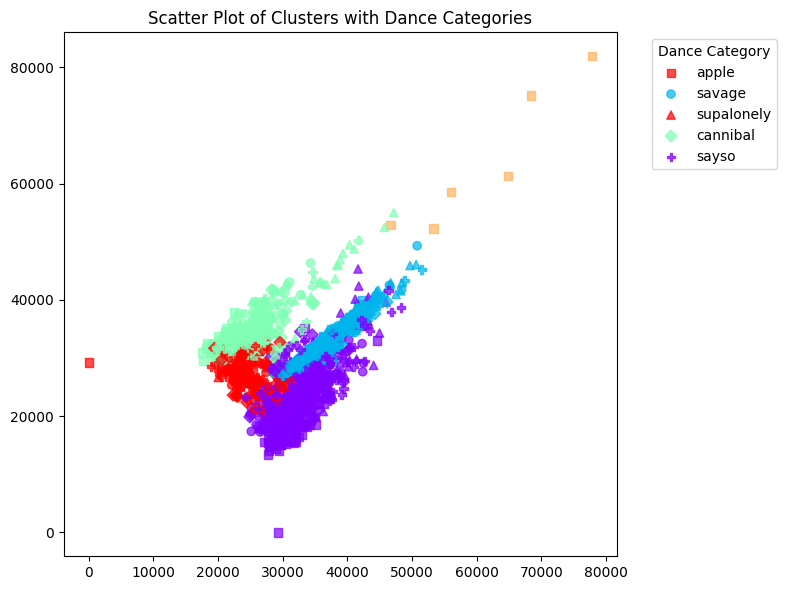

In [74]:
#trying to plotting clusters as scatter plot with each dance as a different shape
dance_shapes = {
    "apple": "s",      
    "savage": "o",      
    "supalonely": "^", 
    "cannibal": "D",    
    "sayso": "P" 
}

videos = []
dance_labels = []

#labels for dances
for dance, sequences in all_videos_dict.items():
    for seq in sequences:
        videos.append(seq)
        dance_labels.append(dance)
        
fig, ax = plt.subplots(figsize=(8, 6))

#plot each point based on dtew matrix
for dance, marker in dance_shapes.items():
    indices = [i for i, name in enumerate(dance_labels) if name == dance]
    ax.scatter(dtw_matrix[indices, 0], dtw_matrix[indices, 1], 
               c=[Z1.labels_[i] for i in indices], cmap='rainbow', 
               marker=marker, label=dance, alpha=0.7)

ax.legend(title="Dance Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Scatter Plot of Clusters with Dance Categories')
plt.tight_layout()
plt.show()

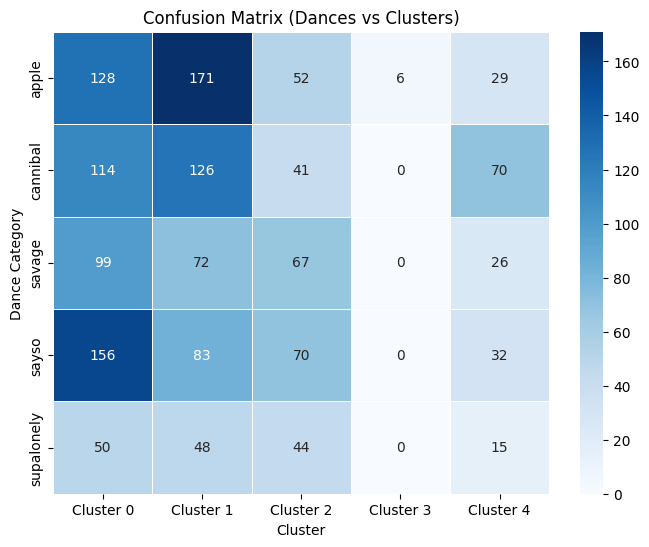

In [75]:
#plotting confusion matrix 
from sklearn.metrics import confusion_matrix
import seaborn as sns

dance_to_index = {dance: i for i, dance in enumerate(sorted(set(dance_labels)))}
dance_numeric_labels = [dance_to_index[dance] for dance in dance_labels]
conf_matrix_agglo = confusion_matrix(dance_numeric_labels, cluster_labels_agglo)

dance_names = sorted(set(dance_labels))
cluster_names_agglo = [f"Cluster {i}" for i in sorted(set(cluster_labels_agglo))]
conf_matrix_df_agglo = pd.DataFrame(conf_matrix_agglo, index=dance_names, columns=cluster_names_agglo)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df_agglo, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Cluster")
plt.ylabel("Dance Category")
plt.title("Confusion Matrix (Dances vs Clusters)")
plt.show()

In [76]:
#metrics
from sklearn import metrics
print(f"agglomerative accuracy: {metrics.accuracy_score(dance_numeric_labels, cluster_labels_agglo) * 100:.2f}%")
print(f"agglomerative f1: {metrics.f1_score(dance_numeric_labels, cluster_labels_agglo, average = 'weighted') * 100:.2f}%")
print(f"agglomerative recall: {metrics.recall_score(dance_numeric_labels, cluster_labels_agglo, average = 'weighted') * 100:.2f}%")
print(f"agglomerative precision: {metrics.precision_score(dance_numeric_labels, cluster_labels_agglo, average = 'weighted') * 100:.2f}%")

agglomerative accuracy: 22.41%
agglomerative f1: 19.34%
agglomerative recall: 22.41%
agglomerative precision: 17.15%


**Time Series Kmeans**

In [53]:
dancing_videos = all_videos[all_videos['dancing']== 'yes']

In [54]:
X = np.array(dancing_videos['padded_normalised_alphapose'].tolist())

In [ ]:
#trying time series kmeans - didn't work very well, took ages to run
#https://levelup.gitconnected.com/unveiling-patterns-in-time-a-guide-to-time-series-clustering-with-tslearn-50a2ff305afe 
#https://tslearn.readthedocs.io/en/stable/user_guide/clustering.html

from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

seed = 0
np.random.seed(seed)

n_clusters = 5 #5 videos

#scale videos
scaler = TimeSeriesScalerMeanVariance()
time_series_dataset_scaled = scaler.fit_transform(X)

model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", verbose = True)

y_pred = model.fit_predict(time_series_dataset_scaled)

In [ ]:
n_clusters = 5


plt.figure(figsize=(10, 6))
for i, series in enumerate(time_series_dataset_scaled):
    cluster = y_pred[i]  
    plt.plot(series.ravel(), color=colors[cluster], alpha=0.5) #flatten series

plt.title("Time Series Clusters (DTW KMeans)")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Values")
plt.show()

In [ ]:
#plot confusion matrix
conf_matrix_tskmeans = confusion_matrix(dance_numeric_labels, cluster_labels_tskmeans)


cluster_names_tskmeans = [f"Cluster {i}" for i in sorted(set(cluster_labels_tskmeans))]
conf_matrix_df_tskmeans = pd.DataFrame(conf_matrix_tskmeans, index=dance_names, columns=cluster_names_tskmeans)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df_tskmeans, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Cluster")
plt.ylabel("Dance Category")
plt.title("Confusion Matrix (Dances vs Clusters)")
plt.show()

In [ ]:
#get metrics
print(f"time series kmeans accuracy: {metrics.accuracy_score(dance_numeric_labels, cluster_labels_tskmeans) * 100:.2f}%")
print(f"time series kmeans f1: {metrics.f1_score(dance_numeric_labels, cluster_labels_tskmeans, average = 'weighted') * 100:.2f}%")
print(f"time series kmeans recall: {metrics.recall_score(dance_numeric_labels, cluster_labels_tskmeans, average = 'weighted') * 100:.2f}%")
print(f"time series kmeans precision: {metrics.precision_score(dance_numeric_labels, cluster_labels_tskmeans, average = 'weighted') * 100:.2f}%")

**DBSCAN**

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
#https://scikit-learn.org/dev/auto_examples/cluster/plot_dbscan.html 

In [82]:
db = DBSCAN(eps=0.5, min_samples=2, metric = 'precomputed').fit(dtw_matrix)
labels = db.labels_

#number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 0
Estimated number of noise points: 1499


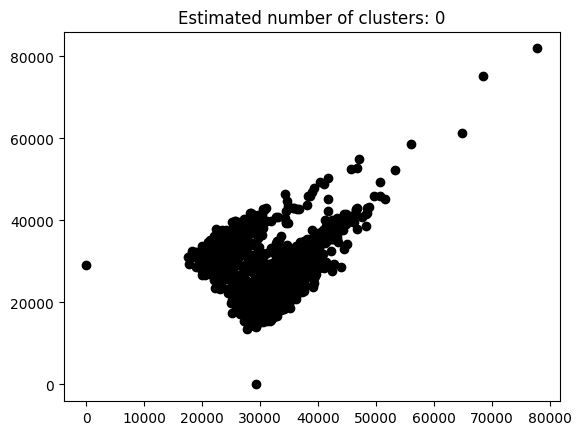

In [83]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = dtw_matrix[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = dtw_matrix[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

In [58]:
apple_coords_padded_list = [np.array(seq) for seq in apple_coords_padded]
savage_coords_padded_list = [np.array(seq) for seq in savage_coords_padded]
sayso_coords_padded_list = [np.array(seq) for seq in sayso_coords_padded]
cannibal_coords_padded_list = [np.array(seq) for seq in cannibal_coords_padded]
supalonely_coords_padded_list = [np.array(seq) for seq in supalonely_coords_padded]

#combine them into one list
all_videos_padded = apple_coords_padded_list + savage_coords_padded_list + sayso_coords_padded_list + cannibal_coords_padded_list + supalonely_coords_padded_list

In [59]:
np.array(all_videos_padded).shape

(1499, 10788, 34)

In [60]:
all_coords_stacked = np.vstack((apple_coords_padded_list, savage_coords_padded_list, cannibal_coords_padded_list, sayso_coords_padded_list, supalonely_coords_padded_list))

In [62]:
all_coords_stacked.shape

(1499, 10788, 34)

In [61]:
all_videos_stacked = np.vstack(all_videos_padded)

In [90]:
all_videos_stacked.shape

(16171212, 34)

In [ ]:
#times out kernel, too much data, not good method
db = DBSCAN(eps=0.1, min_samples=2).fit(all_videos_stacked)
labels = db.labels_

#number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

In [ ]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = all_coordinates[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = all_coordinates[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

**kmeans**

In [64]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(all_videos_stacked)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


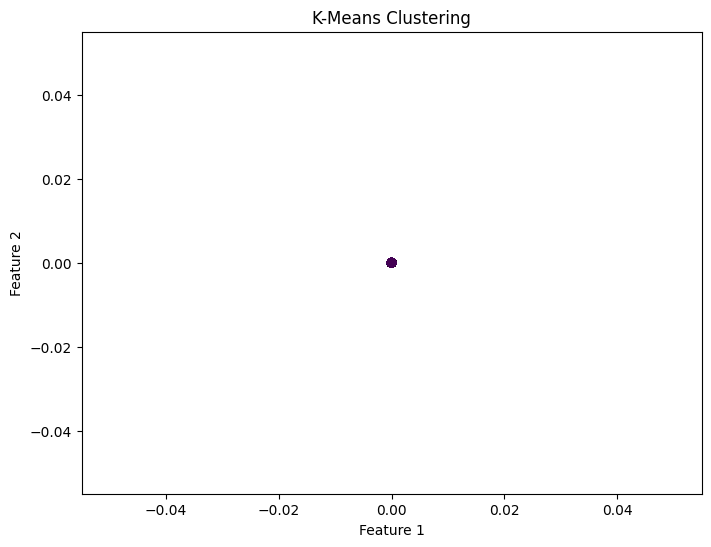

In [66]:
plt.figure(figsize=(8, 6))
plt.scatter(all_videos_stacked[:, 0], all_videos_stacked[:, 1], c=clusters, cmap='viridis', alpha=0.6)


#plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
#plt.legend()
plt.show()